In [1]:
import torch
torch.cuda.is_available()


True

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

In [15]:
class ConditionalAutoencoder(nn.Module):
    def __init__(self, input_dim, label_dim, latent_dim, output_dim):
        super(ConditionalAutoencoder, self).__init__()
        self.input_dim = input_dim
        self.label_dim = label_dim
        self.latent_dim = latent_dim
        self.output_dim = output_dim

        # Encoder
        # self.fc1 = nn.Linear(input_dim + label_dim, 512)
        # self.fc2 = nn.Linear(512, latent_dim)
        self.fc1 = nn.Linear(input_dim + label_dim, latent_dim)
        self.fc2 = nn.Linear(latent_dim, output_dim)

        # Decoder
        # self.fc3 = nn.Linear(latent_dim + label_dim, 512)
        # self.fc4 = nn.Linear(512, input_dim)
        self.fc3 = nn.Linear(output_dim + label_dim, latent_dim)
        self.fc4 = nn.Linear(latent_dim, input_dim)

    def encode(self, x, c):
        x = torch.cat([x, c], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

    def decode(self, z, c):
        z = torch.cat([z, c], dim=1)
        z = F.relu(self.fc3(z))
        z = torch.sigmoid(self.fc4(z))
        return z

    def forward(self, x, c):
        z = self.encode(x, c)
        return self.decode(z, c)

In [16]:
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
# Hyperparameters
input_dim = 784  # MNIST images are 28x28 pixels
label_dim = 10  # MNIST images have 10 labels
latent_dim = 128
output_dim = 64
learning_rate = 0.001
num_epochs = 40
batch_size = 64

In [18]:
# Load the MNIST dataset
# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
# train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
train_data = MNIST(root="./data", train=True, transform=ToTensor(), download=True)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [19]:
# Initialize the model and optimizer
model = ConditionalAutoencoder(input_dim, label_dim, latent_dim, output_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Loss function
criterion = nn.MSELoss()

In [23]:
# Training loop
total_steps = len(train_loader)
for epoch in range(num_epochs):  # number of epochs
    for i, (data, labels) in enumerate(train_loader):
        # Flatten the data and one-hot encode the labels
        data = data.to(device)
        labels = labels.to(device)
        data = data.view(data.size(0), -1)
        labels = F.one_hot(labels, num_classes=label_dim)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        recon_data = model(data, labels.float())

        # Compute the loss
        loss = criterion(recon_data, data)

        # Add the contractive loss
        for param in model.parameters():
            if len(param.shape) == 2:  # Only add for weight matrices
                loss += torch.mean(param**2)

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        # if (i + 1) % 50 == 0:
        #     print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_steps}], Loss: {loss.item():.4f}")

    # Print the loss for this epoch
    print(f'Epoch {epoch+1}, Loss: {loss.item()}')



Epoch 1, Loss: 0.0687270388007164
Epoch 2, Loss: 0.06003395840525627
Epoch 3, Loss: 0.045274265110492706
Epoch 4, Loss: 0.03780809044837952
Epoch 5, Loss: 0.03398197516798973
Epoch 6, Loss: 0.03150486573576927
Epoch 7, Loss: 0.03263409808278084
Epoch 8, Loss: 0.03183416277170181
Epoch 9, Loss: 0.03277837112545967
Epoch 10, Loss: 0.029085462912917137
Epoch 11, Loss: 0.0331244096159935
Epoch 12, Loss: 0.028792357072234154
Epoch 13, Loss: 0.03060266561806202
Epoch 14, Loss: 0.03068026341497898
Epoch 15, Loss: 0.027078865095973015
Epoch 16, Loss: 0.029238969087600708
Epoch 17, Loss: 0.02938559651374817
Epoch 18, Loss: 0.02952374517917633
Epoch 19, Loss: 0.03090433031320572
Epoch 20, Loss: 0.0288871917873621
Epoch 21, Loss: 0.02585151419043541
Epoch 22, Loss: 0.027964770793914795
Epoch 23, Loss: 0.02750883251428604
Epoch 24, Loss: 0.029570702463388443
Epoch 25, Loss: 0.027904357761144638
Epoch 26, Loss: 0.028531119227409363
Epoch 27, Loss: 0.024103010073304176
Epoch 28, Loss: 0.023996608331

In [29]:
# Now that the model is trained, we can use it to generate reconstructions
# for arbitrary labels. For example, let's generate reconstructions for
# the first 10 data points, but with the label for "5" for all of them.

# Get the first 10 data points and their labels
data, _ = next(iter(train_loader))
data = data[:10].view(-1, 784)  # Reshape the data to have shape (10, 784)

# Apply the same transformation as during training
data = (data - 0.5) / 0.5

# Create labels for "5"
labels = torch.zeros(10, 10)
labels[:, 5] = 1

# Generate reconstructions
with torch.no_grad():
    recon_data = model(data.to(device), labels.to(device).float())
# The variable `recon_data` now contains the reconstructions of the first
# 10 data points as if they all had the label "5".

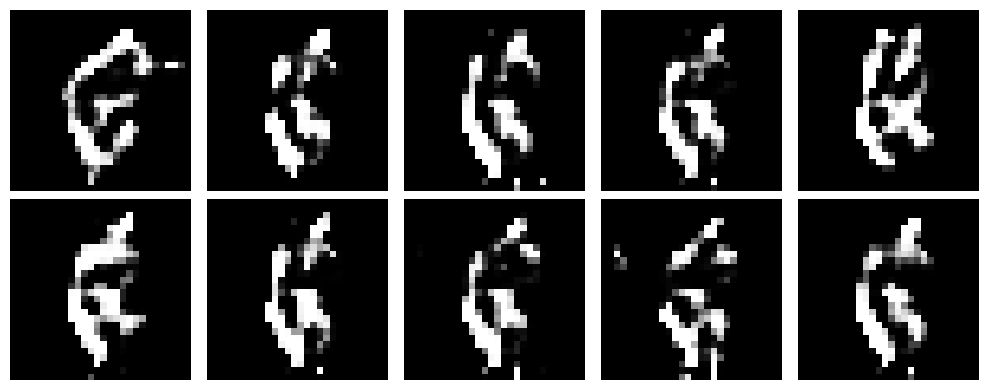

In [42]:
import matplotlib.pyplot as plt

# Reshape the reconstructions to have shape (28, 28)
recon_data = recon_data.cpu().view(-1, 28, 28).detach().numpy()

# Plot the reconstructions
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(recon_data[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()


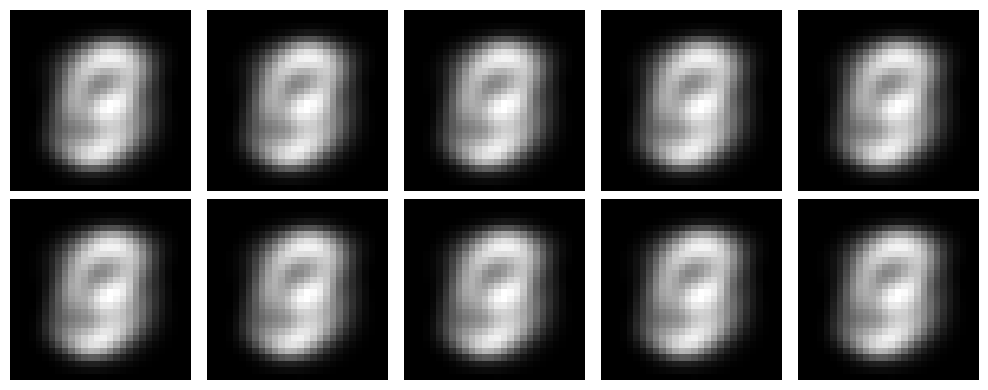

In [22]:
import matplotlib.pyplot as plt

# Reshape the reconstructions to have shape (28, 28)
recon_data = recon_data.cpu().view(-1, 28, 28).detach().numpy()

# Plot the reconstructions
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(recon_data[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

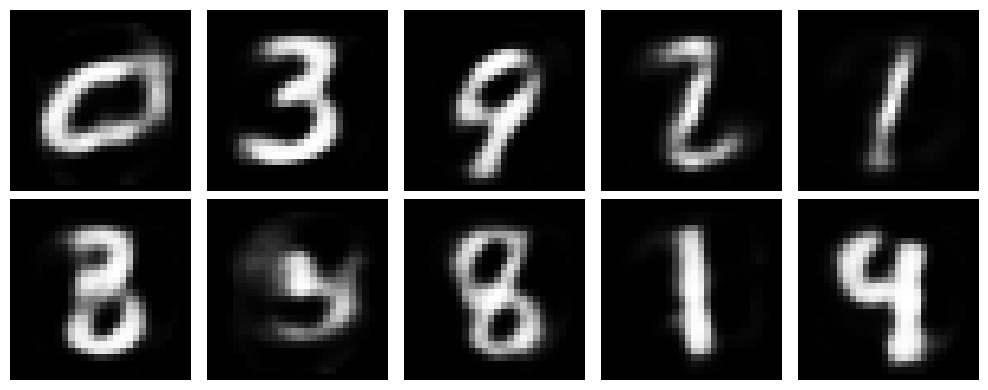

In [24]:
import matplotlib.pyplot as plt

# Reshape the reconstructions to have shape (28, 28)
recon_data = recon_data.cpu().view(-1, 28, 28).detach().numpy()

# Plot the reconstructions
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(recon_data[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

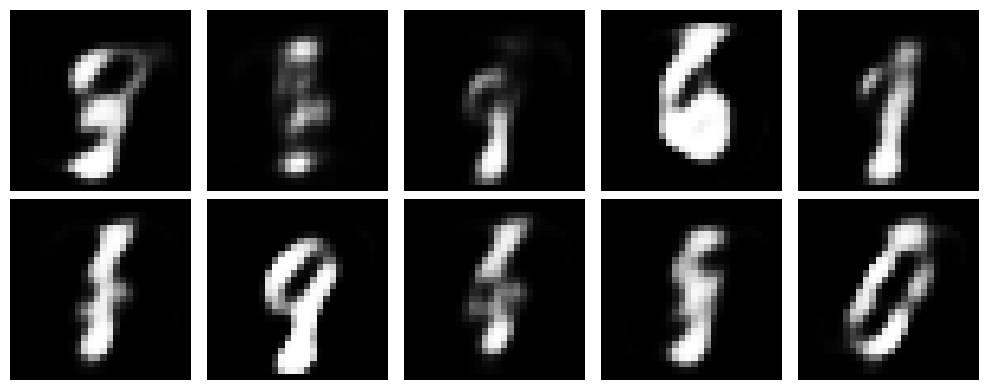

In [30]:
plt.show()
import matplotlib.pyplot as plt

# Reshape the reconstructions to have shape (28, 28)
recon_data = recon_data.cpu().view(-1, 28, 28).detach().numpy()

# Plot the reconstructions
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(recon_data[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()